## Feature Engineering :

In [18]:
# It is the process of using domain knowledge to extract features from raw data. These features can be used to improve perfomance of ML algorithm.

 #### Feature Scaling : 

It is the technique to standardize the independent features present in the data in a fixed range.

In [19]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

# Create dataset folder in your project
target_dir = "./dataset"
os.makedirs(target_dir, exist_ok=True)

# Copy files
for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), target_dir)

print("Dataset copied to:", target_dir)

Dataset copied to: ./dataset


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df=pd.read_csv("dataset/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [22]:
df=df.iloc[:,2:]

In [23]:
df.sample(5)

,Age,EstimatedSalary,Purchased
40,27,17000,0
0,19,19000,0
33,28,44000,0
210,48,96000,1
47,27,54000,0


#### Train Test Split

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.3)

In [25]:
X_train.shape

(280, 2)

#### Standard Scaler

In [26]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [27]:
# mean of each feature column across all rows
print(scaler.mean_) 
print(scaler.scale_)
print(scaler.var_)

[3.7325e+01 7.0650e+04]
[1.04961600e+01 3.40867433e+04]
[1.10169375e+02 1.16190607e+09]


In [28]:
X_train_scaled

array([[-1.07896602,  0.03960484],
       [ 0.82649274,  0.74369088],
       [-0.60260133, -1.6325995 ],
       [-1.84114952,  0.33297402],
       [-1.55533071,  0.03960484],
       [ 0.92176567, -0.81116579],
       [ 0.15958217,  1.85849377],
       [ 0.92176567,  2.15186295],
       [-0.69787427,  0.47965861],
       [-1.17423896,  0.27430018],
       [ 0.44540098,  0.06894176],
       [ 0.25485511, -0.28310126],
       [-0.22150958, -0.37111201],
       [-0.98369308, -1.16320881],
       [ 1.01703861,  2.06385219],
       [ 0.25485511,  0.21562635],
       [-0.31678252, -0.81116579],
       [ 2.16031386,  1.09573389],
       [-0.22150958, -0.95785038],
       [ 0.44540098,  2.29854754],
       [-0.0309637 ,  0.03960484],
       [-0.12623664, -0.48845969],
       [ 1.01703861,  0.56766937],
       [-1.17423896, -1.10453497],
       [-0.50732839,  0.86103855],
       [ 0.82649274,  0.33297402],
       [-0.88842015,  1.53578767],
       [-0.88842015, -0.3417751 ],
       [-0.12623664,

In [29]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [30]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.3,70650.0
std,10.5,34147.8
min,18.0,15000.0
25%,29.0,44750.0
50%,37.0,70500.0
75%,45.2,88000.0
max,60.0,150000.0


In [31]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,-0.0
std,1.0,1.0
min,-1.8,-1.6
25%,-0.8,-0.8
50%,-0.0,-0.0
75%,0.8,0.5
max,2.2,2.3


#### Effect of Scaling

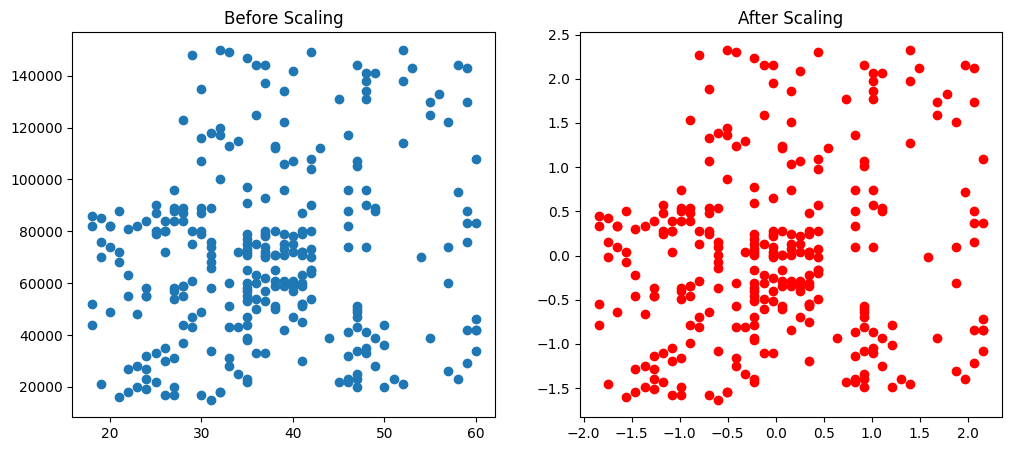

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After Scaling")
plt.show()

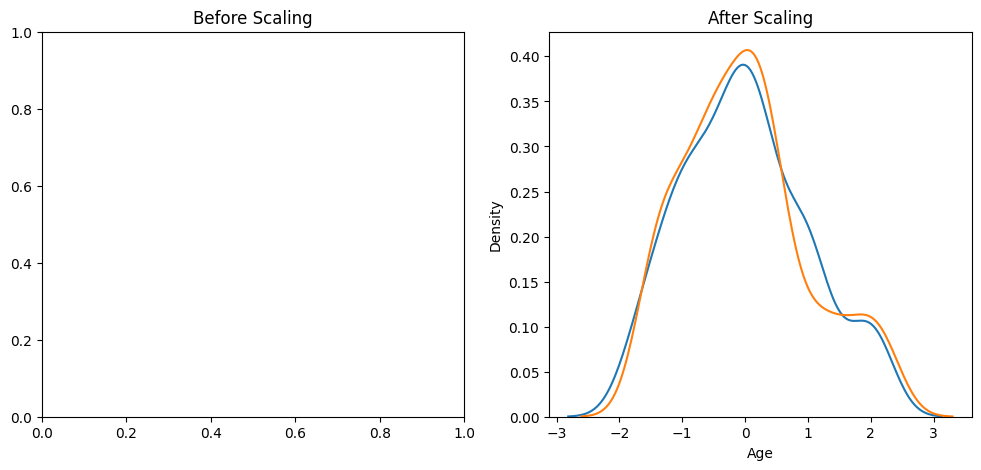

In [40]:
fig, (ax1 ,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Before Scaling")
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Age"],ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"],ax=ax2)
plt.show()

#### Comparison of Distribution

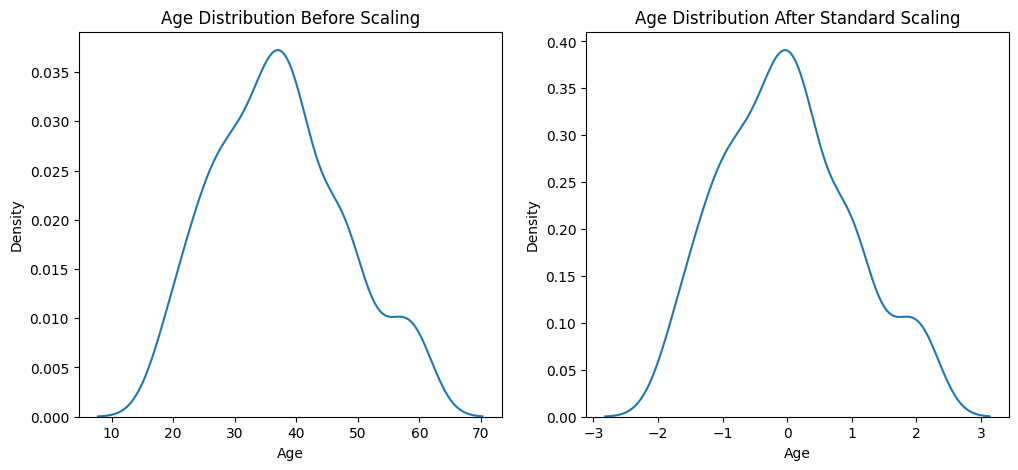

In [41]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(X_train["Age"],ax=ax1)

# after scaling
ax2.set_title("Age Distribution After Standard Scaling")
sns.kdeplot(X_train_scaled["Age"],ax=ax2)
plt.show()

#### Why Scaling is important?

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [49]:
# Train the model first
lr.fit(X_train, y_train)

# Then predict
y_pred = lr.predict(X_test)


# Same for scaled version
lr_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = lr_scaled.predict(X_test_scaled)